In [2]:
import pandas as pd
import numpy as np
import re
import time
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from pymorphy3 import MorphAnalyzer
from nltk.corpus import stopwords
from tqdm.auto import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.utils import resample

# Настройки отображения
pd.set_option('display.max_colwidth', 100)
tqdm.pandas()

nltk.download('stopwords', quiet=True)
russian_stopwords = set(stopwords.words("russian"))
english_stopwords = set(stopwords.words("english"))
all_stopwords = russian_stopwords.union(english_stopwords)

morph = MorphAnalyzer()
print("Библиотеки загружены.")

Библиотеки загружены.


In [3]:
print(len(stopwords.words("russian")))
print(len(stopwords.words("english")))

151
198


In [4]:
import os


output_dir = "test_samples"

try:
    os.makedirs(output_dir, exist_ok=True)
    df = pd.read_csv('../../data/messages.csv') 
    print(f"Загружено строк: {len(df)}")
except FileNotFoundError:
    print("Файл не найден!")
    df = pd.DataFrame({
        'id': range(1000), 
        'text': ['Авария 100\nОписание: Тест сбоя\nНазначено: Группа'] * 1000
    })

# Выборка 300 строк
gold_300 = df.sample(300, random_state=42).copy()
gold_300['manual_label'] = '' #колонка для разметки
gold_300.to_excel(
    os.path.join(output_dir, "GOLD_STANDARD_300.xlsx"),
    index=False
)
print("Файл 'GOLD_STANDARD_300.xlsx' создан. (Для быстрой проверки)")

# Выборка 500 строк 
gold_500 = df.sample(500, random_state=1).copy() # random_state изменён, чтобы строки были другие
gold_500['manual_label'] = ''#колонка для разметки
gold_500.to_excel(
    os.path.join(output_dir, "GOLD_STANDARD_500.xlsx"),
    index=False
)
print("Файл 'GOLD_STANDARD_500.xlsx' создан. (Основной вариант)")

Загружено строк: 45842
Файл 'GOLD_STANDARD_300.xlsx' создан. (Для быстрой проверки)
Файл 'GOLD_STANDARD_500.xlsx' создан. (Основной вариант)


In [5]:
def clean_message(text):
    text = str(text)

    # Убираем \r, нормализуем переносы
    text = text.replace('\r', '\n')

    # Общий шаблон конца блока
    end_pattern = r'(Назначено на группу:|Назначено:|DION:|Тех\.стек:|$)'

    # Функция проверки: только цифры
    def is_only_digits(s):
        return bool(re.fullmatch(r'\d+', s))

    # 1. Описание
    m = re.search(
        rf'Описание:\s*(.*?){end_pattern}',
        text,
        flags=re.S | re.I
    )
    if m:
        part = m.group(1).strip()

        # Если НЕ просто число — возвращаем
        if not is_only_digits(part):
            return part

    # 2. Авария
    m = re.search(
        rf'Авария[^\n:]*:\s*(.*?){end_pattern}',
        text,
        flags=re.S | re.I
    )
    if m:
        return m.group(1).strip()

    # 3. Назначено на группу
    m = re.search(
        rf'Назначено на группу:\s*(.*?){end_pattern}',
        text,
        flags=re.S | re.I
    )
    if m:
        return m.group(1).strip()

    # 4. Фолбэк — третья строка (в первой айди, во второй название)
    lines = [l.strip() for l in text.split('\n') if l.strip()]

    if len(lines) >= 3:
        return lines[2]

    elif len(lines) >= 2:
        return lines[1]

    elif len(lines) >= 1:
        return lines[0]

    return text.strip()

print("Начинаем парсинг полей...")
df['parsed_text'] = df['text'].progress_apply(clean_message)

# Посмотрим, что получилось (Сравнение ДО и ПОСЛЕ)
print("\nПримеры очистки:")
display(df[['text', 'parsed_text']].head())

Начинаем парсинг полей...


  0%|          | 0/45842 [00:00<?, ?it/s]


Примеры очистки:


,text,parsed_text
0,Авария 10001\nИС: Keycloak IdP\nОписание: 1018\nНазначено на группу: Платёжные системы\nDION: ht...,Платёжные системы
1,Авария 10002\nИС: GitLab CI\nОписание: 3500\nНазначено на группу: Операционный мониторинг\nDION:...,Операционный мониторинг
2,Авария 10003\nИС: Deposits Back-Office\nОписание: Недоступность API авторизации. HTTP 500 при вы...,Недоступность API авторизации. HTTP 500 при вызове /auth/login.
3,Авария 10004\nИС: ElasticSearch\nОписание: 1018\nНазначено на группу: Core Analysts\nDION: https...,Core Analysts
4,Авария 10005\nИС: Monitoring (Zabbix)\nОписание: Высокая загрузка CPU ( > 95% ) на узле los-app0...,Высокая загрузка CPU ( > 95% ) на узле los-app03.


In [6]:
def preprocess_text_pymorphy(text: str, morph_analyzer: MorphAnalyzer, stopwords_set: set) -> str:
    """
    Обработка текста: нижний регистр -> удаление спецсимволов -> лемматизация.
    Оставляем русские и АНГЛИЙСКИЕ буквы (CPU, Redis, Error - важны!).
    """
    text = str(text).lower()
    
    text = re.sub(r'[^а-яА-ЯёЁa-zA-Z\s]', ' ', text)
    
    tokens = text.split()
    lemmatized_tokens = []
    for word in tokens:
        if word not in stopwords_set:
            # лемматизация русских слов
            if re.match(r'[а-яё]', word):
                norm_form = morph_analyzer.parse(word)[0].normal_form
                lemmatized_tokens.append(norm_form)
            else:
                # английское (cpu, error)
                lemmatized_tokens.append(word)
    
    return " ".join(lemmatized_tokens)

print(f"\n--- Запуск полной предобработки (Pymorphy) ---")
start_time = time.time()

df['clean_text'] = df['parsed_text'].progress_apply(
    lambda text: preprocess_text_pymorphy(text, morph, all_stopwords)
)

print(f"Время обработки: {time.time() - start_time:.2f} сек.")

df_clean = df[df['clean_text'].str.len() > 2].copy()
print(f"Размер после удаления пустых: {len(df_clean)}")


--- Запуск полной предобработки (Pymorphy) ---


  0%|          | 0/45842 [00:00<?, ?it/s]

Время обработки: 20.01 сек.
Размер после удаления пустых: 44842


In [7]:
df_clean.to_csv('../../data/research_clean_data.csv', index=False)
display(df_clean[['parsed_text', 'clean_text']].head())

,parsed_text,clean_text
0,Платёжные системы,платёжный система
1,Операционный мониторинг,операционный мониторинг
2,Недоступность API авторизации. HTTP 500 при вызове /auth/login.,недоступность api авторизация http вызов auth login
3,Core Analysts,core analysts
4,Высокая загрузка CPU ( > 95% ) на узле los-app03.,высокий загрузка cpu узел los app


Матрица признаков: (44842, 715)
Запуск анализа локтевого метода...


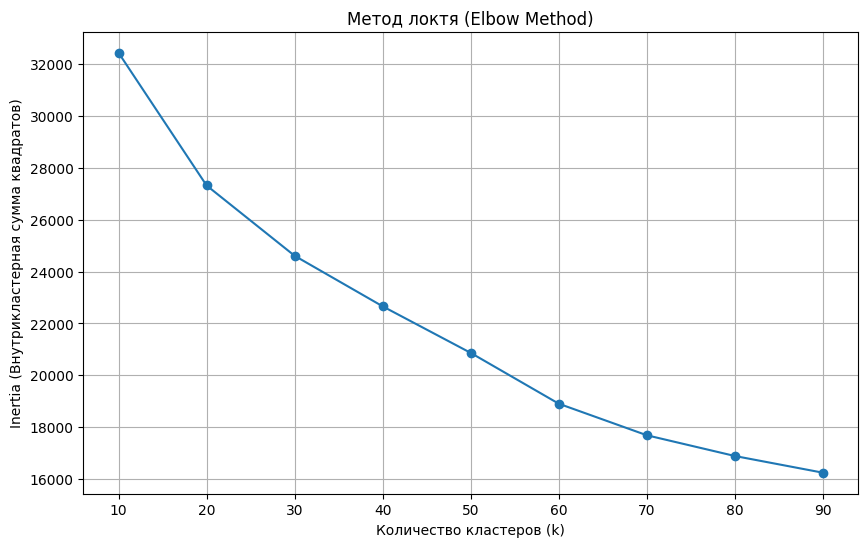

In [8]:
vectorizer = TfidfVectorizer(max_features=2000, min_df=5, max_df=0.95)
X = vectorizer.fit_transform(df_clean['clean_text'])
print(f"Матрица признаков: {X.shape}")

inertia = []
K_range = range(10, 100, 10) #проверка от 10 до 90 кластеров с шагом 10

print("Запуск анализа локтевого метода...")
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Inertia (Внутрикластерная сумма квадратов)')
plt.title('Метод локтя (Elbow Method)')
plt.grid(True)
plt.show()

In [9]:
k_best = 30
kmeans = KMeans(n_clusters=k_best, random_state=42, n_init='auto')
labels = kmeans.fit_predict(X)

df_clean['cluster_label'] = labels

X_sample, labels_sample = resample(X, labels, n_samples=5000, random_state=42)

print(f"--- Метрики на ОЧИЩЕННЫХ данных (k={k_best}) ---")
sil_score = silhouette_score(X_sample, labels_sample, metric='cosine')
print(f"Silhouette Score: {sil_score:.4f} (Было ~0.31, ожидаем рост)")

ch_score = calinski_harabasz_score(X_sample.toarray(), labels_sample)
print(f"Calinski-Harabasz Score: {ch_score:.2f}")

db_score = davies_bouldin_score(X_sample.toarray(), labels_sample)
print(f"Davies-Bouldin Score: {db_score:.4f} (Чем ниже, тем лучше)")

--- Метрики на ОЧИЩЕННЫХ данных (k=30) ---
Silhouette Score: 0.3561 (Было ~0.31, ожидаем рост)
Calinski-Harabasz Score: 125.29
Davies-Bouldin Score: 2.3059 (Чем ниже, тем лучше)


Генерация t-SNE визуализации...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 5000 samples in 0.002s...
[t-SNE] Computed neighbors for 5000 samples in 0.121s...
[t-SNE] Computed conditional probabilities for sample 1000 / 5000
[t-SNE] Computed conditional probabilities for sample 2000 / 5000
[t-SNE] Computed conditional probabilities for sample 3000 / 5000
[t-SNE] Computed conditional probabilities for sample 4000 / 5000
[t-SNE] Computed conditional probabilities for sample 5000 / 5000
[t-SNE] Mean sigma: 0.000000
[t-SNE] KL divergence after 250 iterations with early exaggeration: 59.417862
[t-SNE] KL divergence after 1000 iterations: 0.214424


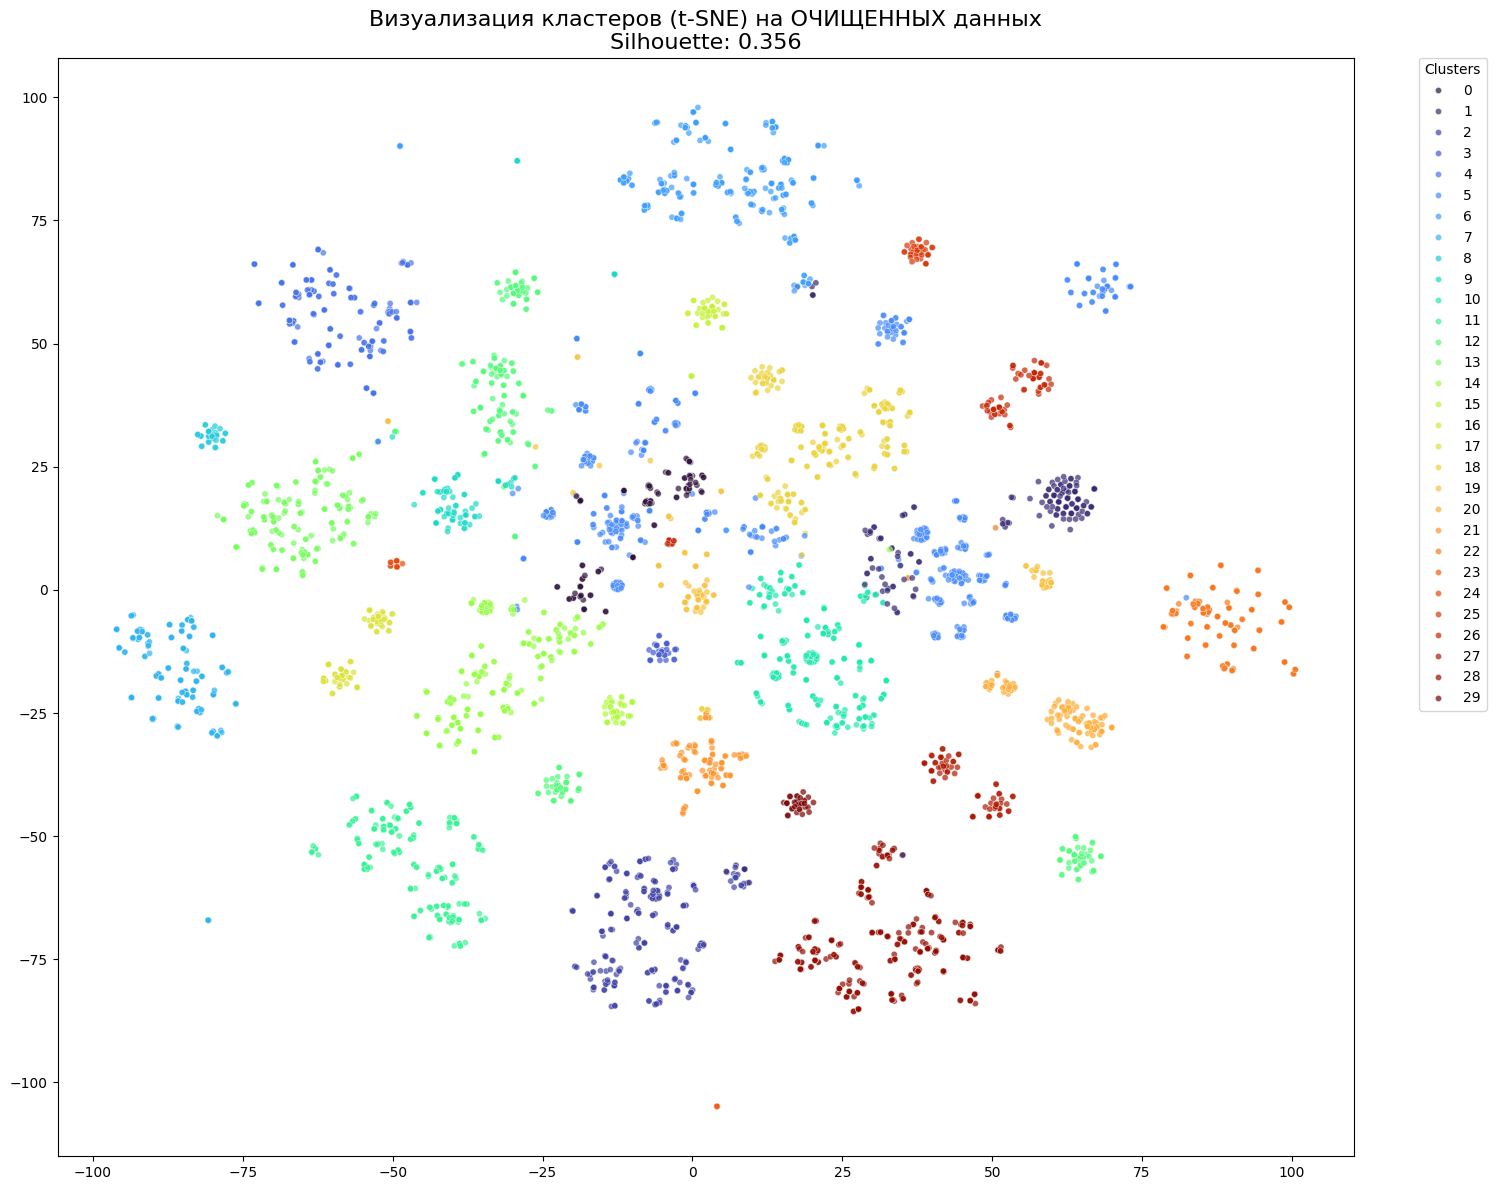

In [10]:
print("Генерация t-SNE визуализации...")

# PCA
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_sample.toarray())

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, verbose=1)
X_embedded = tsne.fit_transform(X_pca)

# График
plt.figure(figsize=(15, 12))
sns.scatterplot(
    x=X_embedded[:, 0], 
    y=X_embedded[:, 1], 
    hue=labels_sample, 
    palette="turbo",
    legend="full",
    s=20,
    alpha=0.7
)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., title=f"Clusters")
plt.title(f'Визуализация кластеров (t-SNE) на ОЧИЩЕННЫХ данных\nSilhouette: {sil_score:.3f}', fontsize=16)
plt.tight_layout()
plt.show()

In [11]:
print("--- Топ слова в кластерах (После очистки) ---")
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]
terms = vectorizer.get_feature_names_out()

for i in range(30):
    print(f"Cluster {i}: ", end='')
    top_terms = [terms[ind] for ind in order_centroids[i, :7]]
    print(", ".join(top_terms))

--- Топ слова в кластерах (После очистки) ---
Cluster 0: данные, база, выполнить, начать, ora, соединение, куратор
Cluster 1: em, ru, servicedesk, https, рис, авария, prod
Cluster 2: ов, pod, kubernetes, deployment, namespace, падение, prod
Cluster 3: уровень, достигнуть, диск, использование, критический, node, gw
Cluster 4: failed, состояние, остановить, сервис, репликация, postgresql, systemd
Cluster 5: ошибка, snmp, ru, em, servicedesk, ул, timeout
Cluster 6: replica, lag, сечь, postgresql, хост, репликация, ошибка
Cluster 7: карта, перегрузить, авторизация, узел, cpu, ошибка, bank
Cluster 8: load, обновление, мина, метрика, отсутствовать, хост, cpu
Cluster 9: загрузка, пакет, высокий, cpu, задерживаться, наблюдаться, производительность
Cluster 10: http, недоступность, авторизация, api, auth, обращение, bank
Cluster 11: гипервизора, heartbeat, отсутствовать, подозрение, сбой, bank, lan
Cluster 12: превысить, порог, память, количество, температура, cpu, хост
Cluster 13: нагрузка, зам

In [12]:
print("--- Анализ содержания кластеров для разметки (Mapping) ---")

# Получаем список слов для заголовков (чтобы видеть контекст сразу)
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]
terms = vectorizer.get_feature_names_out()

# Проходим по всем 30 кластерам
for i in range(30):
    # 1. Формируем заголовок с топ-5 словами
    top_terms = [terms[ind] for ind in order_centroids[i, :5]]
    print(f"\n========== КЛАСТЕР {i} | Ключи: {', '.join(top_terms)} ==========")
    
    # 2. Фильтруем данные (берем только строки этого кластера)
    # ВАЖНО: используем df_clean и колонку 'cluster_label', которую мы создали ранее
    cluster_df = df_clean[df_clean['cluster_label'] == i]
    
    count = len(cluster_df)
    print(f"Всего сообщений: {count}")

    # 3. Берем выборку (5 штук)
    sample_size = min(5, count)
    
    if sample_size > 0:
        # random_state=42 фиксирует выбор, чтобы при перезапуске показывались те же примеры
        examples = cluster_df['text'].sample(n=sample_size, random_state=42).tolist()
        
        for idx, text in enumerate(examples):
            # Убираем переносы строк (\n) и лишние пробелы для читаемости
            clean_text = str(text).replace('\n', ' // ').replace('\r', '')
            
            # Если текст очень длинный, обрезаем до 200 символов
            if len(clean_text) > 200:
                clean_text = clean_text[:200] + "..."
                
            print(f"{idx+1}. {clean_text}")
    else:
        print("(Кластер пуст)")

--- Анализ содержания кластеров для разметки (Mapping) ---

========== КЛАСТЕР 0 | Ключи: данные, база, выполнить, начать, ora ==========
Всего сообщений: 995
1. Начат: 14.09.25 Выполнение ETL-процесса
2. Выполнен: 05.09.25 Обновление справочников по клиентам (ручная проверка)
3. Выполнен: 26.09.25 Пересчет агрегатов по счетам (автоматический запуск)
4. Начат: 29.04.25 Запуск расчетных процедур департамента (автоматический запуск)
5. Выполнен: 10.05.25 Проверка консистентности данных в хранилище по расписанию

========== КЛАСТЕР 1 | Ключи: em, ru, servicedesk, https, рис ==========
Всего сообщений: 2207
1. Подозрение на широкомасштабный сбой по КЕ: Keycloak IdP_PROD, более 15 аварий за 15 минут  // Авария: [EM-52228] (https://servicedesk.ru/EM-52228) // DION: http Опис:s://meet.banгk.local/room/esb
2. Подозрнеие на широкомасштабный сбой по КЕ: OpCon Batch_PROD, более 15 аварий за 15 минут  // Авария: [EM-52305] (https://servicedesk.ru/EM-52305) // DION: https://meet.bank.local/room/mon

In [ ]:
cluster_map = {
    0: 'APP_ZOD',
    1: 'INFRA_SYSTEM_WIDESPREAD_FAILURE_ALERT',
    2: 'INFRA_K8S_POD_RESTART_FAILURE',
    3: 'INFRA_DISK_SPACE_CRITICAL',
    4: 'INFRA_POSTGRES_SERVICE_STATUS_FAILED',
    5: 'INFRA_NETWORK_OR_REMOTE_TIMEOUT',
    6: 'INFRA_POSTGRES_REPLICATION_LAG',
    7: 'APP_CARD_AUTH_BUSINESS_ERROR',
    8: 'INFRA_MONITORING_METRIC_MISSING',
    9: 'INFRA_CPU_HIGH_USAGE',
    10: 'APP_API_AUTH_500_ERROR',
    11: 'INFRA_HYPERVISOR_HEARTBEAT_LOST',
    12: 'INFRA_HARDWARE_OR_LOG_THRESHOLD', 
    13: 'INFRA_CPU_HIGH_USAGE', 
    14: 'INFRA_ORACLE_TNS_LISTENER_ERROR',
    15: 'INFRA_STORAGE_RO_OR_MOUNT_FAIL',
    16: 'INFRA_CONNECTION_REFUSED',
    17: 'INFRA_MONITORING_AGENT_DOWN',
    18: 'INFRA_TLS_HANDSHAKE_OR_PORT_443',
    19: 'INFRA_NETWORK_LATENCY_RTT',
    20: 'INFRA_DISK_SPACE_CRITICAL', 
    21: 'APP_FINBANK_FUNCTIONAL_UNAVAILABILITY', 
    22: 'APP_INTERNAL_ERROR_CODES',
    23: 'INFRA_JDBC_CONNECTION_POOL_EXHAUSTED', 
    24: 'INFRA_WEB_SERVER_IIS_OWA_FAIL',
    25: 'INFRA_NETWORK_BANDWIDTH_EXCEEDED',
    26: 'INFRA_MESSAGE_BROKER_QUEUE_OVERFLOW',
    27: 'INFRA_NETWORK_LATENCY_RTT',
    28: 'INFRA_POSTGRES_WALARCHIVE_FULL',
    29: 'INFRA_STORAGE_RO_OR_MOUNT_FAIL',
}

df_clean['pseudo_label'] = df_clean['cluster_label'].map(cluster_map)

df_train = df_clean[df_clean['pseudo_label'] != 'OTHER'].copy()
df_train.to_csv('TRAIN_DATASET_WITH_LABELS.csv', index=False)